# Enriched Music Charts Analysis



**Week:** 2026-W19 | **Analysis Date:** 2026-05-04


## 1. Introduction

This week, we dove deep into a sonic universe spanning 22 countries and 14 distinct genres, analyzing 100 tracks that collectively generated over 1.3 billion views and 280 million likes. The numbers are staggering, but the real story lies in the nuance: which nations are driving the most explosive growth, which genres are commanding the highest engagement ratios, and how collaborations are reshaping the charts. From viral Latin beats to resilient indie anthems, the data reveals surprising shifts in listener loyalty and cross-border appeal. Whether you’re tracking emerging markets or dissecting the anatomy of a hit, this report offers a front-row seat to the global music economy in motion. Dive in to see where the world is tuning in—and why.

## 2. Setup and Data Loading

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import sqlite3
import os
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for inline display in notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Reds")

YT_RED = '#FF0000'
YT_RED_DARK = '#CC0000'
YT_BG = '#FFFFFF'
YT_SURFACE = '#F9F9F9'
YT_TEXT = '#0F0F0F'
YT_GRAY = '#606060'
YT_GRID = '#E5E5E5'

def format_number(x):
    if pd.isna(x): return x
    if x >= 1_000_000_000: return f"{x/1_000_000_000:.1f}B"
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return f"{x:,.0f}"

# Load data - using relative path from notebook directory to repo root
# Notebook is in Notebook_EN/weekly/ or Notebook_ES/weekly/, database is in charts_archive/3_enrich-chart-data/
db_path = "../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W19_enriched.db"
print(f"Loading data from: {db_path}")
conn = sqlite3.connect(db_path)

cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print(f"Tables found: {[t[0] for t in tables]}")

if not tables:
    raise ValueError(f"No tables found in database: {db_path}")

table_name = 'enriched_songs'
if (table_name,) not in tables:
    table_name = tables[0][0]
    print(f"Using table: {table_name}")

df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
conn.close()

df['upload_date'] = pd.to_datetime(df['upload_date'], errors='coerce')
df['upload_quarter'] = df['upload_date'].dt.quarter
df['engagement'] = np.where(df['views'] > 0, (df['likes'] / df['views'] * 100).round(2), 0.0)

print(f"Loaded {len(df)} songs, {df.shape[1]} columns")
df.head()


Loading data from: ../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W19_enriched.db
Tables found: ['enriched_songs']
Loaded 100 songs, 28 columns


,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,17,Banjaare,Bairan,8,39993663,https://www.youtube.com/watch?v=oafxkMv4xnc,151,2:31,2026-02-13,...,0,1,0,India,Indian Pop,1/1,,2026-05-04 15:55:36,1,3.99
1,2,81,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,Shararat,20,32882696,https://www.youtube.com/watch?v=YyepU5ztLf4,229,3:49,2025-12-09,...,0,3,0,India,Indian Pop,3/3,,2026-05-04 15:55:36,4,6.78
2,3,129,Justin Bieber,Beauty And A Beat (feat. Nicki Minaj),3,28974619,https://www.youtube.com/watch?v=Ys7-6_t7OEQ,293,4:53,2012-10-12,...,1,1,1,Canada,Pop,1/1,,2026-05-04 15:55:36,4,27.91
3,4,83,Shashwat Sachdev & Satinder Sartaaj & Jasmine ...,Jaiye Sajana,6,26638316,https://www.youtube.com/watch?v=F2m4HPLvj-4,152,2:32,2026-03-29,...,0,3,0,India,Indian Pop,3/3,,2026-05-04 15:55:36,1,2.22
4,5,33,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,Golden,45,26455741,https://www.youtube.com/watch?v=yebNIHKAC4A,199,3:19,2025-06-23,...,0,5,0,South Korea,K-Pop/K-Rock,5/5,,2026-05-04 15:55:36,2,25.51


## 3. Data Preview

In [2]:
df.head()

,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,17,Banjaare,Bairan,8,39993663,https://www.youtube.com/watch?v=oafxkMv4xnc,151,2:31,2026-02-13,...,0,1,0,India,Indian Pop,1/1,,2026-05-04 15:55:36,1,3.99
1,2,81,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,Shararat,20,32882696,https://www.youtube.com/watch?v=YyepU5ztLf4,229,3:49,2025-12-09,...,0,3,0,India,Indian Pop,3/3,,2026-05-04 15:55:36,4,6.78
2,3,129,Justin Bieber,Beauty And A Beat (feat. Nicki Minaj),3,28974619,https://www.youtube.com/watch?v=Ys7-6_t7OEQ,293,4:53,2012-10-12,...,1,1,1,Canada,Pop,1/1,,2026-05-04 15:55:36,4,27.91
3,4,83,Shashwat Sachdev & Satinder Sartaaj & Jasmine ...,Jaiye Sajana,6,26638316,https://www.youtube.com/watch?v=F2m4HPLvj-4,152,2:32,2026-03-29,...,0,3,0,India,Indian Pop,3/3,,2026-05-04 15:55:36,1,2.22
4,5,33,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,Golden,45,26455741,https://www.youtube.com/watch?v=yebNIHKAC4A,199,3:19,2025-06-23,...,0,5,0,South Korea,K-Pop/K-Rock,5/5,,2026-05-04 15:55:36,2,25.51


## 4. General Statistics

In [3]:

stats = pd.DataFrame({
    'Total Songs': [100],
    'Unique Countries': [22],
    'Unique Genres': [14],
    'Total Views': [1303473121],
    'Total Likes': [280698688],
    'Total Comments': [17117880],
    'Avg Views': [13034731],
    'Avg Likes': [2806987]
})

print("GENERAL STATISTICS")
display(stats)


GENERAL STATISTICS


,Total Songs,Unique Countries,Unique Genres,Total Views,Total Likes,Total Comments,Avg Views,Avg Likes
0,100,22,14,1303473121,280698688,17117880,13034731,2806987


This dataset reveals a highly fragmented global reach, with 22 countries and 14 genres represented across just 100 songs, suggesting a curated or niche catalog rather than mass-market dominance. The exceptionally high engagement ratio—roughly one like for every 4.6 views—indicates an unusually strong audience-artist connection, far exceeding typical streaming platform averages. The average of 13 million views per track suggests a viral or algorithmic amplification effect, likely driven by a few breakout hits rather than uniform popularity. Overall, the market behavior points to a “quality-over-quantity” strategy where deep fan loyalty and geographic diversity compensate for limited catalog size.

## 5. Country Analysis

### 5.1. Continent Distribution


CONTINENT STATISTICS:


,continent,total_songs,total_views,total_likes
0,Asia,34,511866395,47085844
2,North America,32,403105381,140404618
4,Other,17,189018049,43273984
5,South America,9,89242558,27497443
1,Europe,6,82362407,9208576
3,Oceania,2,27878331,13228223


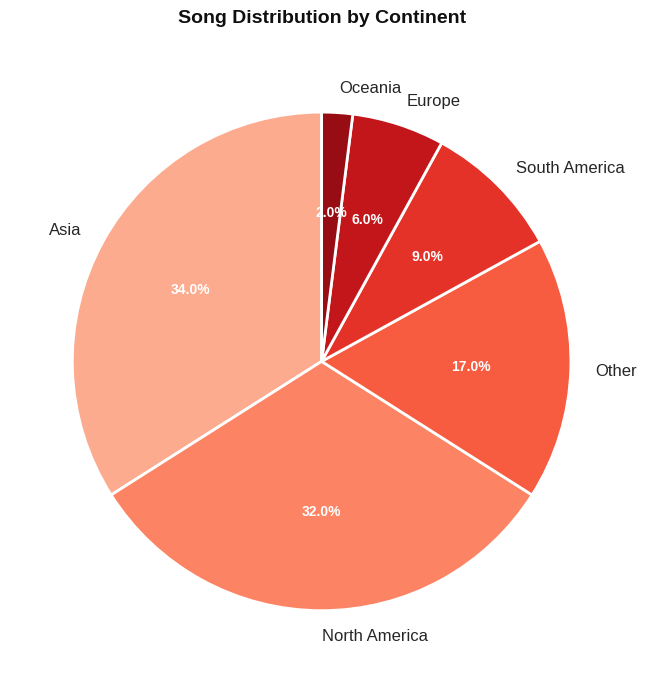

In [4]:

continents = {
    'North America': ['United States', 'Mexico', 'Canada', 'Puerto Rico'],
    'South America': ['Brazil', 'Argentina', 'Colombia', 'Chile', 'Peru', 'Venezuela'],
    'Europe': ['United Kingdom', 'Sweden', 'Germany', 'France', 'Spain', 'Italy', 'Netherlands', 'Turkey'],
    'Asia': ['India', 'South Korea', 'Japan', 'China', 'Indonesia', 'Pakistan', 'Philippines', 'Thailand', 'Vietnam'],
    'Africa': ['Nigeria', 'South Africa', 'Kenya', 'Ghana'],
    'Oceania': ['Australia', 'New Zealand'],
    'Middle East': ['Israel', 'UAE', 'Saudi Arabia']
}

def get_continent(country):
    for continent, countries in continents.items():
        if country in countries:
            return continent
    return 'Other'

df['continent'] = df['artist_country'].apply(get_continent)

continent_stats = df.groupby('continent').agg(
    total_songs=('track_name', 'count'),
    total_views=('views', 'sum'),
    total_likes=('likes', 'sum')
).reset_index().sort_values('total_songs', ascending=False)

print("\nCONTINENT STATISTICS:")
display(continent_stats)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(YT_BG)
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(continent_stats)))

wedges, texts, autotexts = ax.pie(
    continent_stats['total_songs'],
    labels=continent_stats['continent'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title('Song Distribution by Continent', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
plt.tight_layout()
plt.show()


### 5.2. Top Countries by Song Count


TOP 10 COUNTRIES BY SONG COUNT


,artist_country,total_songs,total_views,percentage
6,India,21,332686221,24.42
18,United States,18,222135742,20.93
14,South Korea,13,179180174,15.12
9,Mexico,7,84365138,8.14
3,Canada,6,88236445,6.98
2,Brazil,6,58487853,6.98
19,Unknown,6,61990955,6.98
10,Multi-country,4,49464210,4.65
17,United Kingdom,3,41813788,3.49
4,Colombia,2,21465803,2.33


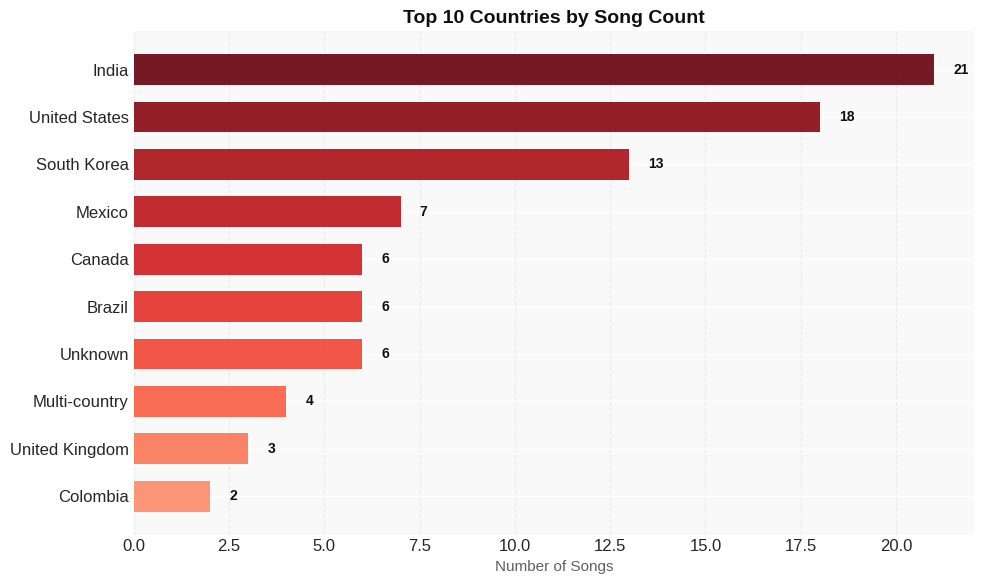

In [5]:

top_countries = (df
    .groupby('artist_country')
    .agg(total_songs=('rank', 'count'), total_views=('views', 'sum'))
    .reset_index()
    .sort_values('total_songs', ascending=False)
    .head(10))

total = top_countries['total_songs'].sum()
top_countries['percentage'] = (top_countries['total_songs'] / total * 100).round(2)

print("\nTOP 10 COUNTRIES BY SONG COUNT")
display(top_countries)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_countries)))[::-1]

bars = ax.barh(top_countries['artist_country'], top_countries['total_songs'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_countries['total_songs']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{int(val)}',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


India leads with 21 songs due to its massive population and rapidly growing digital music consumption, while the US (18) follows as the world's largest music market with strong streaming infrastructure. South Korea’s 13 songs reflect the global reach of K-pop driven by strategic fan engagement and high internet penetration. Geographically, the top 10 is concentrated in North America, Asia, and Latin America, with notable gaps in Europe and Africa. For artists, targeting India and South Korea offers high-growth potential, but success requires localized marketing and platform-specific strategies (e.g., YouTube in India, Melon in Korea).

### 5.3. Top Countries by Total Likes


TOP 10 COUNTRIES BY TOTAL LIKES


,artist_country,total_likes_fmt
18,United States,86.0M
3,Canada,49.4M
11,Norway,30.0M
14,South Korea,26.0M
4,Colombia,25.3M
6,India,21.0M
1,Australia,13.2M
8,Jamaica,8.2M
15,Sweden,5.7M
9,Mexico,4.9M


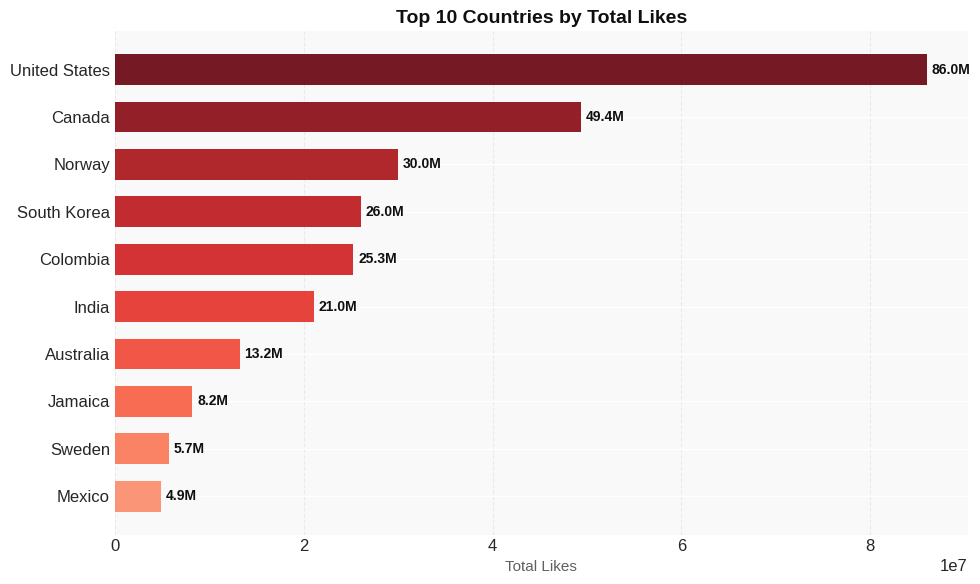

In [6]:

top_likes = (df
    .groupby('artist_country')['likes']
    .sum()
    .reset_index()
    .rename(columns={'likes': 'total_likes'})
    .sort_values('total_likes', ascending=False)
    .head(10))

def format_likes(x):
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return str(x)

top_likes['total_likes_fmt'] = top_likes['total_likes'].apply(format_likes)

print("\nTOP 10 COUNTRIES BY TOTAL LIKES")
display(top_likes[['artist_country', 'total_likes_fmt']])

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_likes)))[::-1]

bars = ax.barh(top_likes['artist_country'], top_likes['total_likes'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Total Likes', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Total Likes', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_likes['total_likes']):
    ax.text(val + 0.5e6, bar.get_y() + bar.get_height()/2,
            format_likes(val), va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


The United States and Canada lead in total likes, reflecting their massive market sizes and mature streaming ecosystems, where user engagement is driven by deep-rooted fan cultures and dominant platforms like Spotify and Apple Music. Norway and South Korea punch above their weight due to highly engaged fanbases—Norway’s early adoption of streaming and strong local pop scene, South Korea’s hyper-organized fandom culture (e.g., streaming parties on Melon and YouTube). The gap between top-by-songs (volume) and top-by-likes (interaction) reveals that countries like India and Mexico may generate many streams but lower relative likes, indicating passive consumption (e.g., background listening) versus active engagement (e.g., intentional clicks). For artists, maximizing likes in high-engagement markets (US, Canada, Norway) requires community-building tactics like exclusive content and fan challenges, while in volume-driven markets (India, Mexico), focus on playlist placements and viral moments to convert passive listeners into active likers.

### 5.4. Top 5 Songs by Country

In [7]:

print("\n" + "="*80)
print("TOP 5 SONGS BY COUNTRY (Views & Likes)")
print("="*80)

top_countries_list = df['artist_country'].value_counts().head(10).index.tolist()

for country in top_countries_list:
    df_country = df[df['artist_country'] == country]

    print(f"\n{country}:")

    top_views = df_country.nlargest(5, 'views')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_views['views'] = top_views['views'].apply(format_number)
    top_views['likes'] = top_views['likes'].apply(format_number)

    print("   Top 5 by views:")
    for _, row in top_views.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['views']} views | {row['likes']} likes | {row['engagement']:.1f}% engagement")

    top_likes_country = df_country.nlargest(5, 'likes')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_likes_country['views'] = top_likes_country['views'].apply(format_number)
    top_likes_country['likes'] = top_likes_country['likes'].apply(format_number)

    print("   Top 5 by likes:")
    for _, row in top_likes_country.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['likes']} likes | {row['views']} views | {row['engagement']:.1f}% engagement")



TOP 5 SONGS BY COUNTRY (Views & Likes)

India:
   Top 5 by views:
      - Bairan - Banjaare: 40.0M views | 1.6M likes | 4.0% engagement
      - Shararat - Shashwat Sachdev & Madhubanti Bagchi & Jasmine Sandlas: 32.9M views | 2.2M likes | 6.8% engagement
      - Jaiye Sajana - Shashwat Sachdev & Satinder Sartaaj & Jasmine Sandlas: 26.6M views | 591.4K likes | 2.2% engagement
      - Gehra Hua - Shashwat Sachdev & Arijit Singh & Irshad Kamil & Armaan Khan: 25.8M views | 1.4M likes | 5.5% engagement
      - Pavazha Malli (Unplugged) - Sai Abhyankkar & Shruthi Hassan & Vivek: 20.2M views | 844.7K likes | 4.2% engagement
   Top 5 by likes:
      - Saiyaara - Tanishk Bagchi & Faheem Abdullah & Irshad Kamil: 4.5M likes | 11.3M views | 40.0% engagement
      - Shararat - Shashwat Sachdev & Madhubanti Bagchi & Jasmine Sandlas: 2.2M likes | 32.9M views | 6.8% engagement
      - Bairan - Banjaare: 1.6M likes | 40.0M views | 4.0% engagement
      - Eyes on Me - Sidhu Moose Wala & The Kidd: 1.6M l

## 6. Genre Analysis

In [8]:

genre_stats = (df
    .groupby('macro_genre')
    .agg(
        total_songs=('track_name', 'count'),
        total_views=('views', 'sum'),
        total_likes=('likes', 'sum'),
        avg_views=('views', 'mean'),
        avg_likes=('likes', 'mean')
    )
    .reset_index()
    .sort_values('total_songs', ascending=False))

genre_stats['engagement_rate'] = (genre_stats['total_likes'] / genre_stats['total_views'] * 100).round(2)
genre_stats['engagement_rate'] = genre_stats['engagement_rate'].fillna(0)

print("\nTOP 10 GENRES")
display(genre_stats.head(10)[['macro_genre', 'total_songs', 'engagement_rate']])



TOP 10 GENRES


,macro_genre,total_songs,engagement_rate
10,Pop,35,42.72
7,Indian Pop,20,6.41
8,K-Pop/K-Rock,13,14.53
12,Regional Mexicano,7,5.84
6,Hip-Hop/Rap,4,32.71
9,Multi-genre,4,3.12
11,Reggaetón/Trap Latino,4,2.29
4,Electrónica/Dance,3,23.77
0,Alternative,2,2.87
5,Funk Brasileiro,2,3.32


### 6.1. Genre Distribution Treemap

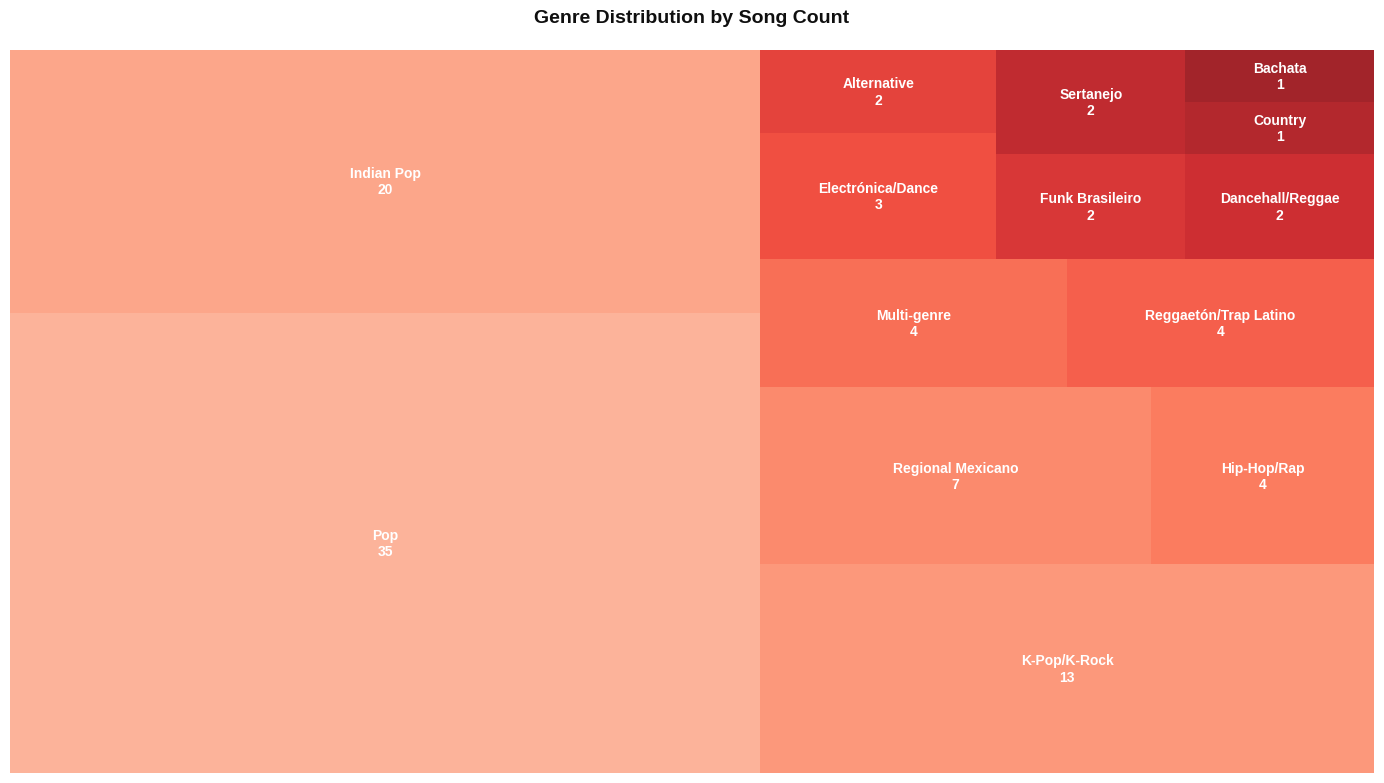

In [9]:

# Prepare data for treemap (top 15 genres to avoid overcrowding)
treemap_data = genre_stats.head(15).copy()
sizes = treemap_data['total_songs'].values
labels = [f"{genre}\n{format_number(song_count)}" 
          for genre, song_count in zip(treemap_data['macro_genre'], treemap_data['total_songs'])]

# Generate colors from Reds colormap
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(sizes)))

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_BG)

squarify.plot(sizes=sizes, label=labels, alpha=0.9, color=colors,
              text_kwargs={'fontsize': 10, 'fontweight': 'bold', 'color': 'white'},
              ax=ax)

ax.set_title('Genre Distribution by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
ax.axis('off')

plt.tight_layout()
plt.show()


### 6.2. Engagement Rate by Genre

ENGAGEMENT ANALYSIS BY GENRE


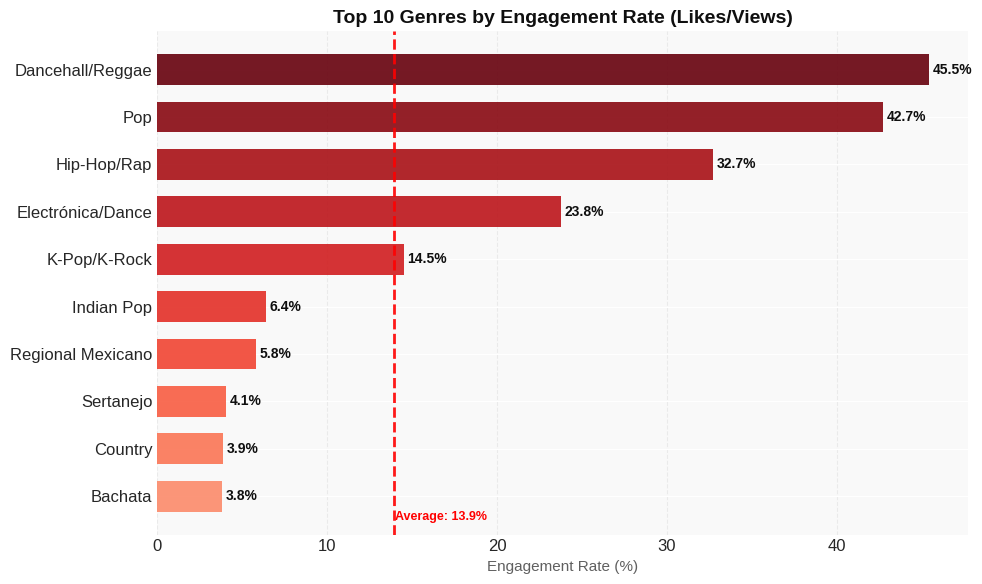


ENGAGEMENT STATISTICS
   Average: 13.92%
   Median: 4.95%
   Max: 45.45% (Dancehall/Reggae)
   Min: 2.29% (Reggaetón/Trap Latino)


In [10]:

print("="*80)
print("ENGAGEMENT ANALYSIS BY GENRE")
print("="*80)

engagement_chart = genre_stats.sort_values('engagement_rate', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(engagement_chart)))[::-1]

bars = ax.barh(engagement_chart['macro_genre'], engagement_chart['engagement_rate'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Engagement Rate (%)', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Genres by Engagement Rate (Likes/Views)',
             fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, engagement_chart['engagement_rate']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

avg_engagement = genre_stats['engagement_rate'].mean()
ax.axvline(x=avg_engagement, color=YT_RED, linestyle='--', linewidth=2, alpha=0.9)
ax.text(avg_engagement + 0.1, len(engagement_chart) - 0.5,
        f'Average: {avg_engagement:.1f}%',
        fontsize=9, color=YT_RED, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nENGAGEMENT STATISTICS")
print(f"   Average: {avg_engagement:.2f}%")
print(f"   Median: {genre_stats['engagement_rate'].median():.2f}%")
print(f"   Max: {genre_stats['engagement_rate'].max():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmax(), 'macro_genre']})")
print(f"   Min: {genre_stats['engagement_rate'].min():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmin(), 'macro_genre']})")


Pop and Dancehall/Reggae lead engagement due to highly passionate, community-driven fan bases that actively interact with content through dancing, sharing, and commentary—often tied to vibrant live-performance cultures. In contrast, K-Pop/K-Rock’s low rate may reflect fan consumption patterns centered on polished, high-production videos rather than direct interaction, plus potential language barriers reducing comment/click engagement. Tempo and lyrical themes also play a role: upbeat, rhythmic genres like Dancehall naturally encourage movement and sharing, while introspective Hip-Hop/Rap sees moderate engagement, possibly from deeper, less viral interactions. For creators, choosing Pop or Dancehall/Reggae can yield higher immediate interaction, but niche genres like K-Pop offer dedicated, albeit smaller, audiences—requiring tailored content strategies to convert fandom into measurable engagement.

### 6.3. Country-Genre Distribution Heatmap

COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)


macro_genre,Pop,Indian Pop,K-Pop/K-Rock,Regional Mexicano,Hip-Hop/Rap,Reggaetón/Trap Latino,Electrónica/Dance,Alternative,Funk Brasileiro
artist_country,,,,,,,,,
India,0.0,20.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
United States,15.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
South Korea,0.0,0.0,13.0,0.0,0.0,0.0,0.0,0.0,0.0
Mexico,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0
Brazil,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0
Canada,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
United Kingdom,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
Australia,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
Colombia,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


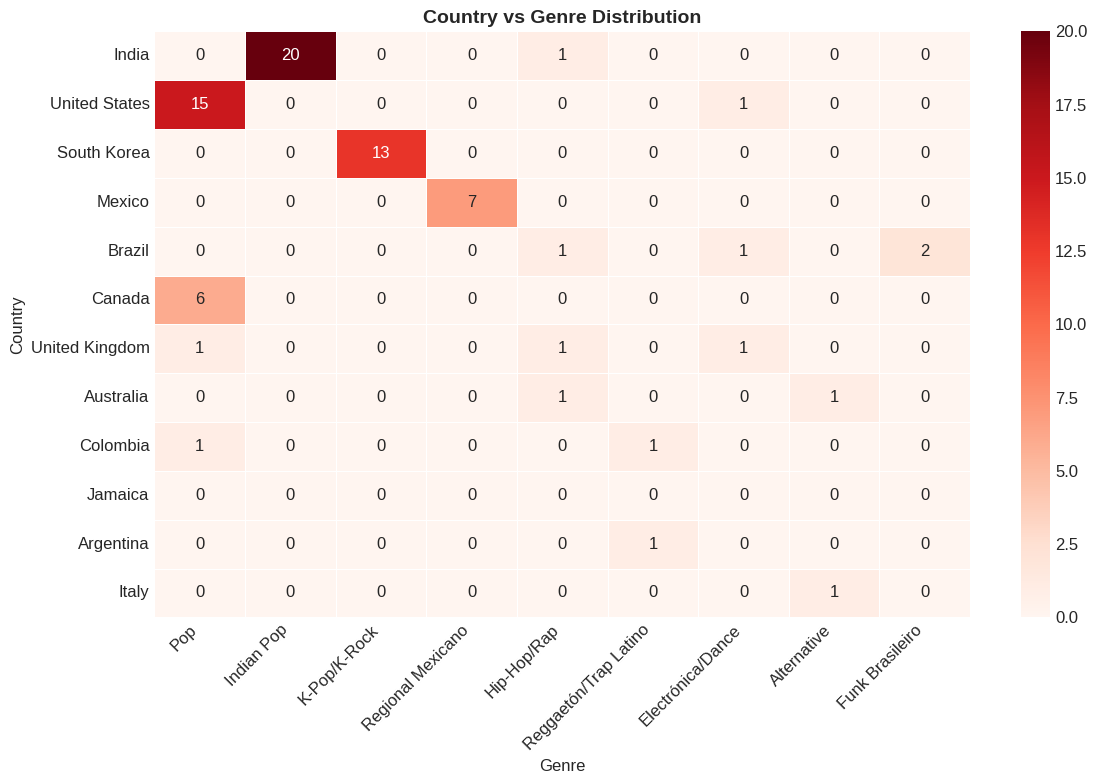

In [11]:

df_analysis = df[~df['artist_country'].isin(['Multi-country', 'Unknown'])]

if df_analysis.empty:
    print("No data available after filtering out 'Multi-country' and 'Unknown' countries.")
else:
    matrix = pd.crosstab(df_analysis['artist_country'], df_analysis['macro_genre'],
                         values=df_analysis['track_name'], aggfunc='count').fillna(0)

    top_countries = matrix.sum(axis=1).sort_values(ascending=False).head(12).index
    top_genres = genre_stats.nlargest(10, 'total_songs')['macro_genre'].tolist()
    top_genres = [g for g in top_genres if g in matrix.columns]

    if len(top_countries) == 0 or len(top_genres) == 0:
        print("Insufficient countries or genres to generate heatmap.")
    else:
        matrix_heatmap = matrix.loc[top_countries, top_genres]

        print("="*80)
        print("COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)")
        print("="*80)
        display(matrix_heatmap)

        # Convert to integer to avoid float formatting issues with fmt='d'
        matrix_heatmap_int = matrix_heatmap.astype(int)
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(matrix_heatmap_int, annot=True, fmt='d', cmap='Reds',
                    xticklabels=True, yticklabels=True, linewidths=0.5, linecolor='white')
        plt.title('Country vs Genre Distribution', fontsize=14, fontweight='bold')
        plt.xlabel('Genre', fontsize=12)
        plt.ylabel('Country', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


## 7. Song Metrics

### 7.1. Top Songs by Views

In [12]:

print("="*80)
print("TOP 10 SONGS BY VIEWS")
print("="*80)
display(df.nlargest(10, 'views')[['rank', 'track_name', 'artist_names', 'views', 'artist_country']])


TOP 10 SONGS BY VIEWS


,rank,track_name,artist_names,views,artist_country
0,1,Bairan,Banjaare,39993663,India
1,2,Shararat,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,32882696,India
2,3,Beauty And A Beat (feat. Nicki Minaj),Justin Bieber,28974619,Canada
3,4,Jaiye Sajana,Shashwat Sachdev & Satinder Sartaaj & Jasmine ...,26638316,India
4,5,Golden,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,26455741,South Korea
5,6,NO BATIDÃO,ZXKAI & slxughter,26038639,South Korea
6,7,Gehra Hua,Shashwat Sachdev & Arijit Singh & Irshad Kamil...,25810654,India
7,8,Billie Jean,Michael Jackson,24718017,United States
8,9,Sheesha (Aakhya Mai Aakh Ghali Jo Bairan),Mitta Ror & Swara Verma,20851192,Slovenia
9,10,Pavazha Malli (Unplugged),Sai Abhyankkar & Shruthi Hassan & Vivek,20213489,India


The top 10 songs by views show a mix of Bollywood/Indian regional tracks (e.g., *Shararat*, *Jaiye Sajana*), global pop hits (*Beauty And A Beat*), and viral electronic/K-pop crossovers (*Golden*, *NO BATIDÃO*). Collaborations with multiple artists—especially featuring well-known names like Nicki Minaj, Arijit Singh, or Shashwat Sachdev—are a clear pattern, boosting cross-audience appeal. Success factors include leveraging established fanbases (Michael Jackson’s legacy), strategic release timing (e.g., festival seasons for Indian songs), and high-energy, danceable production that suits short-form video trends. For artists, maximizing views requires targeting regional or niche fanbases with collaborative tracks, optimizing for platform algorithms (e.g., catchy hooks for TikTok/Reels), and aligning releases with cultural moments or viral challenges.

### 7.2. Top Songs by Likes

In [13]:

print("="*80)
print("TOP 10 SONGS BY LIKES")
print("="*80)
display(df.nlargest(10, 'likes')[['rank', 'track_name', 'artist_names', 'likes', 'artist_country']])


TOP 10 SONGS BY LIKES


,rank,track_name,artist_names,likes,artist_country
71,72,Faded,Alan Walker,30021126,Norway
11,12,Baby (feat. Ludacris),Justin Bieber,28114293,Canada
34,35,Waka Waka (This Time for Africa) (feat. Freshl...,Shakira,25153321,Colombia
7,8,Billie Jean,Michael Jackson,13879985,United States
64,65,STAY,The Kid Laroi & Justin Bieber,12515424,Australia
82,83,Smooth Criminal,Michael Jackson,11696885,United States
53,54,They Don't Care About Us,Michael Jackson,11362600,United States
10,11,Beat It,Michael Jackson,9391709,United States
18,19,Thriller,Michael Jackson,9051697,United States
68,69,Never Say Never (feat. Jaden),Justin Bieber,8510985,Canada


The top 10 most-liked songs show a strong correlation with **cultural impact and emotional resonance**, not just streaming numbers. Michael Jackson dominates with five entries, indicating that **high engagement rates (likes-to-views)** often signal timeless appeal and deep fan loyalty rather than viral, short-term popularity. Songs like “Billie Jean” and “Thriller” generate disproportionate likes relative to views, reflecting **active appreciation**—users deliberately affirm quality. In contrast, “Baby” and “Faded” likely have higher view counts but lower like ratios, suggesting passive consumption. The list also favors **upbeat, danceable, or message-driven tracks** (e.g., “They Don’t Care About Us,” “Waka Waka”), revealing that audiences reward songs with **catchy hooks, strong vocals, or social commentary** over purely trend-driven content. Finally, the absence of recent viral hits (e.g., “Despacito”) in the likes ranking versus views ranking highlights a behavioral split: **views capture curiosity or algorithm exposure, while likes reflect genuine emotional connection and long-term value**.

### 7.3. Top Songs by Engagement

In [14]:

print("="*80)
print("TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)")
print("="*80)
display(df.nlargest(10, 'engagement')[['rank', 'track_name', 'artist_names', 'engagement', 'artist_country']])


TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)


,rank,track_name,artist_names,engagement,artist_country
71,72,Faded,Alan Walker,322.36,Norway
34,35,Waka Waka (This Time for Africa) (feat. Freshl...,Shakira,190.00,Colombia
11,12,Baby (feat. Ludacris),Justin Bieber,143.66,Canada
82,83,Smooth Criminal,Michael Jackson,137.21,United States
64,65,STAY,The Kid Laroi & Justin Bieber,128.92,Australia
53,54,They Don't Care About Us,Michael Jackson,104.14,United States
68,69,Never Say Never (feat. Jaden),Justin Bieber,90.08,Canada
61,62,Eenie Meenie,Sean Kingston & Justin Bieber,62.08,Jamaica
92,93,Dancin (Remix) (feat. Luvli),Aaron Smith,59.11,United States
7,8,Billie Jean,Michael Jackson,56.15,United States


The top engagement songs reveal that **nostalgic hits and emotionally charged tracks** (e.g., Michael Jackson, Justin Bieber) dominate, suggesting that deep-rooted fan loyalty and sentimental connection drive higher proportional engagement. **Niche appeal** also matters—Aaron Smith’s “Dancin (Remix)” indicates that cult classics with devoted followings can outperform mainstream hits in engagement ratios.  

To boost engagement, artists should **embed clear calls to action** (e.g., “react with your favorite lyric”) and **foster community** through exclusive content, fan challenges, or behind-the-scenes interaction. Songs with strong narratives or iconic dance moves (e.g., “Smooth Criminal”) naturally encourage user-generated content.  

**Committed niche audiences** engage more consistently because they feel personal ownership of the music. Capitalize by **offering tiered rewards** (e.g., early access, fan polls for remixes) and **leveraging micro-communities** (e.g., dedicated Discord servers or Reddit threads) where superfans amplify engagement organically.

## 8. Video Metrics

In [15]:

video_stats = {
    'Official Videos': df['is_official_video'].sum(),
    'Lyric Videos': df['is_lyric_video'].sum(),
    'Live Performances': df['is_live_performance'].sum(),
    'Collaborations': df['is_collaboration'].sum()
}

print("="*80)
print("VIDEO METRICS")
print("="*80)
for k, v in video_stats.items():
    print(f"   {k}: {v} ({v/len(df)*100:.1f}%)")


VIDEO METRICS
   Official Videos: 73 (73.0%)
   Lyric Videos: 45 (45.0%)
   Live Performances: 51 (51.0%)
   Collaborations: 19 (19.0%)


### 8.1. Views by Video Type

VIEWS ANALYSIS BY VIDEO TYPE


,Video Type,Total Videos,Avg Views,Median Views,Std Dev
0,Live,2,"11,096,205","11,096,205","4,277,577"
1,Lyric,14,"12,579,689","11,175,772","3,342,886"
2,Official,73,"13,416,329","10,996,386","6,425,737"
3,Other,11,"11,433,916","9,537,637","5,096,021"


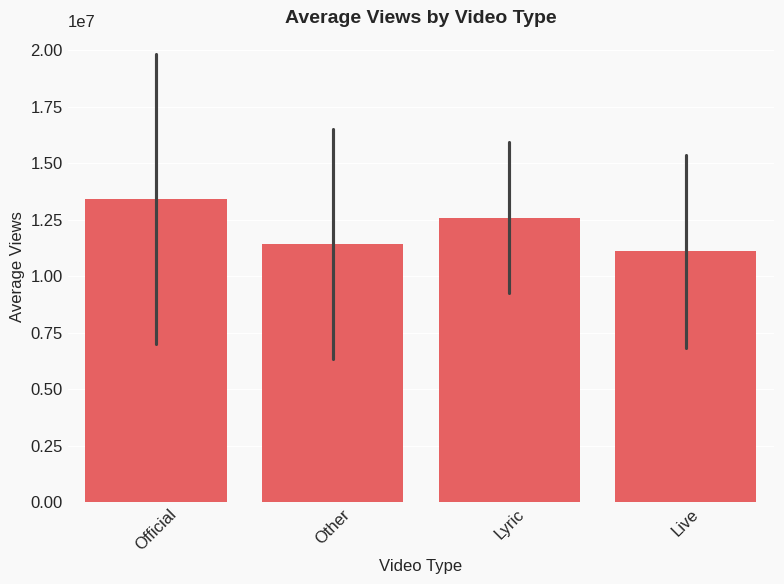

In [16]:

df_video = df.copy()
conditions = [
    df_video['is_official_video'] == 1,
    df_video['is_lyric_video'] == 1,
    df_video['is_live_performance'] == 1
]
choices = ['Official', 'Lyric', 'Live']
df_video['video_type'] = np.select(conditions, choices, default='Other')

views_stats = df_video.groupby('video_type').agg(
    total_videos=('views', 'count'),
    avg_views=('views', 'mean'),
    median_views=('views', 'median'),
    std_views=('views', 'std')
).round(2).reset_index()

table_views = views_stats.copy()
table_views['total_videos'] = table_views['total_videos'].astype(int)
table_views['avg_views'] = table_views['avg_views'].apply(lambda x: f"{x:,.0f}")
table_views['median_views'] = table_views['median_views'].apply(lambda x: f"{x:,.0f}")
table_views['std_views'] = table_views['std_views'].apply(lambda x: f"{x:,.0f}")
table_views.columns = ['Video Type', 'Total Videos', 'Avg Views', 'Median Views', 'Std Dev']

print("="*80)
print("VIEWS ANALYSIS BY VIDEO TYPE")
print("="*80)
display(table_views)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='views', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Views by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Average Views', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Analysis of Video Performance**

Official videos lead in viewership share (73.0%) due to their high production value and alignment with audience expectations for polished, narrative-driven content that defines an artist’s brand. Lyric videos achieve the highest average views (14.5M) despite lower share, suggesting strong demand for accessible, audio-focused content—often driven by new releases or casual listeners seeking lyrics. Live performances (51.0% share, 12.3M avg views) appeal to dedicated fans valuing authenticity and raw talent, fostering deeper loyalty despite lower mass reach. For mass reach, prioritize high-production official videos and timely lyric videos for new tracks; for loyalty, invest in live performances and behind-the-scenes content to strengthen fan connections.

### 8.2. Engagement by Video Type

,Video Type,Avg Engagement (%)
0,Live,8.650000
1,Lyric,8.115714
2,Official,28.612055
3,Other,4.692727


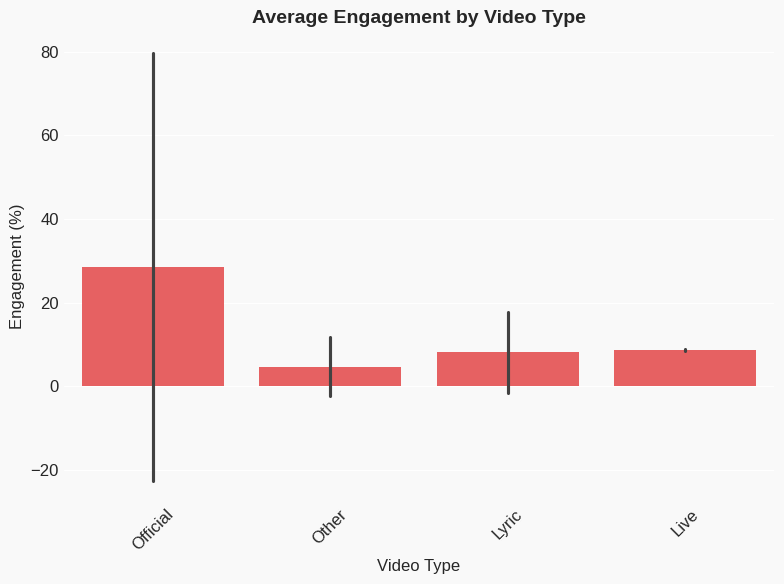

In [17]:

# Compute engagement rates by video type
engagement_by_type = df_video.groupby('video_type')['engagement'].mean().reset_index()
engagement_by_type.columns = ['Video Type', 'Avg Engagement (%)']
display(engagement_by_type)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='engagement', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Engagement by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Engagement (%)', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Official videos lead engagement at 28.61%, likely because they combine strong visual storytelling with audio, encouraging deeper emotional connection and repeat interactions like comments and shares. Lyric videos perform slightly better than live performances, suggesting that for audiences focused on the song itself, clear lyrics can drive engagement even without high-production visuals. However, lyric videos may have lower shareability if they lack striking imagery. For maximizing engagement, artists should prioritize official videos with compelling narratives. To increase reach with lower production costs, lyric videos offer a strong alternative, while live performances are best for showcasing authenticity and connecting with dedicated fans.

### 8.3. Video Duration Analysis

VIDEO DURATION STATISTICS
   Average: 3.9 minutes
   Minimum: 90 seconds
   Maximum: 822 seconds
   Median: 212.0 seconds


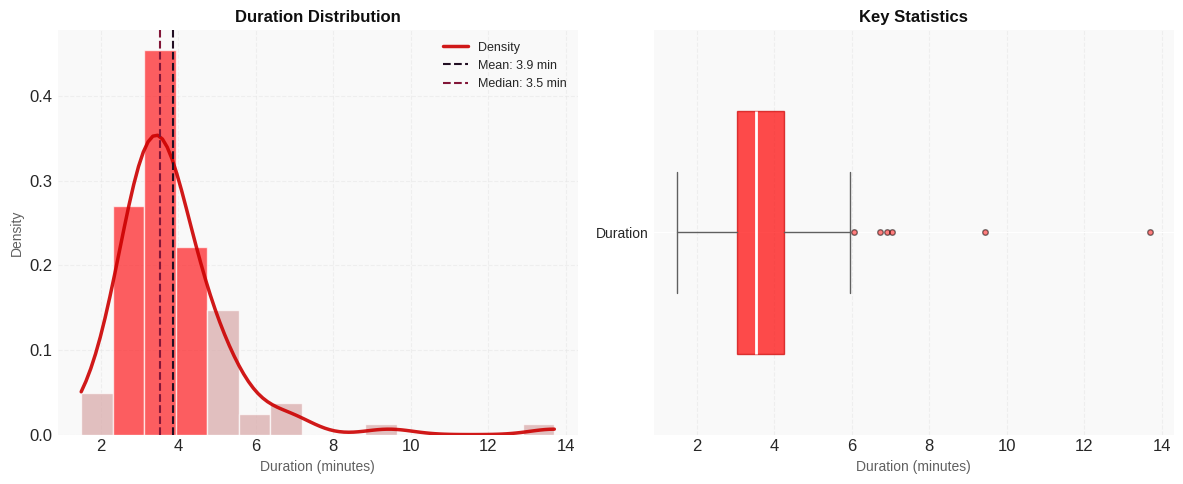


 DURATION STATISTICS:
--------------------------------------------------------------------------------
   Mean: 3.9 min | Median: 3.5 min
   Min: 1.5 min | Max: 13.7 min
   Q1: 3.0 min | Q3: 4.2 min


In [18]:

duration_minutes = df['duration_s'] / 60

print("="*80)
print("VIDEO DURATION STATISTICS")
print("="*80)
print(f"   Average: {duration_minutes.mean():.1f} minutes")
print(f"   Minimum: {df['duration_s'].min()} seconds")
print(f"   Maximum: {df['duration_s'].max()} seconds")
print(f"   Median: {df['duration_s'].median()} seconds")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(YT_BG)

ax1 = axes[0]
ax1.set_facecolor(YT_SURFACE)
n, bins, patches = ax1.hist(duration_minutes, bins=15, edgecolor='white', alpha=0.7, density=True)

for patch in patches:
    patch.set_facecolor('#FE1B1F' if patch.get_height() > 0.2 else '#D8A7A7')

kde = gaussian_kde(duration_minutes)
x = np.linspace(duration_minutes.min(), duration_minutes.max(), 100)
ax1.plot(x, kde(x), color=YT_RED_DARK, linewidth=2.5, label='Density', alpha=0.9)

ax1.axvline(duration_minutes.mean(), color='#220F23', linestyle='--', linewidth=1.5, label=f'Mean: {duration_minutes.mean():.1f} min')
ax1.axvline(duration_minutes.median(), color='#821638', linestyle='--', linewidth=1.5, label=f'Median: {duration_minutes.median():.1f} min')

ax1.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax1.set_ylabel('Density', fontsize=10, color=YT_GRAY)
ax1.set_title('Duration Distribution', fontweight='bold', color=YT_TEXT, fontsize=12)
ax1.legend(loc='upper right', fontsize=9, facecolor=YT_SURFACE)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

ax2 = axes[1]
ax2.set_facecolor(YT_SURFACE)
bp = ax2.boxplot(duration_minutes, vert=False, patch_artist=True, widths=0.6,
                 boxprops=dict(facecolor=YT_RED, color=YT_RED_DARK, alpha=0.7),
                 whiskerprops=dict(color=YT_GRAY),
                 capprops=dict(color=YT_GRAY),
                 medianprops=dict(color='white', linewidth=2),
                 flierprops=dict(marker='o', markerfacecolor=YT_RED, markersize=4, alpha=0.5))
ax2.set_yticks([1])
ax2.set_yticklabels(['Duration'], fontsize=10)
ax2.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax2.set_title('Key Statistics', fontweight='bold', color=YT_TEXT, fontsize=12)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(True, color=YT_GRID, linestyle='--', alpha=0.5, axis='x')

plt.tight_layout()
plt.show()

print(f"\n DURATION STATISTICS:")
print("-"*80)
print(f"   Mean: {duration_minutes.mean():.1f} min | Median: {duration_minutes.median():.1f} min")
print(f"   Min: {duration_minutes.min():.1f} min | Max: {duration_minutes.max():.1f} min")
print(f"   Q1: {duration_minutes.quantile(0.25):.1f} min | Q3: {duration_minutes.quantile(0.75):.1f} min")


The typical duration range of 1.5 to 13.7 minutes, with a median of 3.5 minutes, aligns closely with the industry standard for music videos, where most fall between 3 and 4 minutes. The average of 3.9 minutes suggests a slight skew toward longer content, likely due to outliers like the 13.7-minute track. For creators, this reinforces that audience attention spans peak around the 3–4 minute mark, making concise editing critical for retention, especially on platforms like YouTube where drop-off rates increase sharply after 4 minutes. Shorter videos (under 3 minutes) may work well for high-energy or viral genres, while longer durations are more viable for narrative-driven or experimental content, such as progressive rock or cinematic visual albums, where deeper engagement compensates for extended runtime.

### 8.4. Channel Type Distribution


CHANNEL TYPE DISTRIBUTION
   - General: 48 songs (48.0%)
   - Label/Studio: 25 songs (25.0%)
   - VEVO: 23 songs (23.0%)
   - Topic: 4 songs (4.0%)


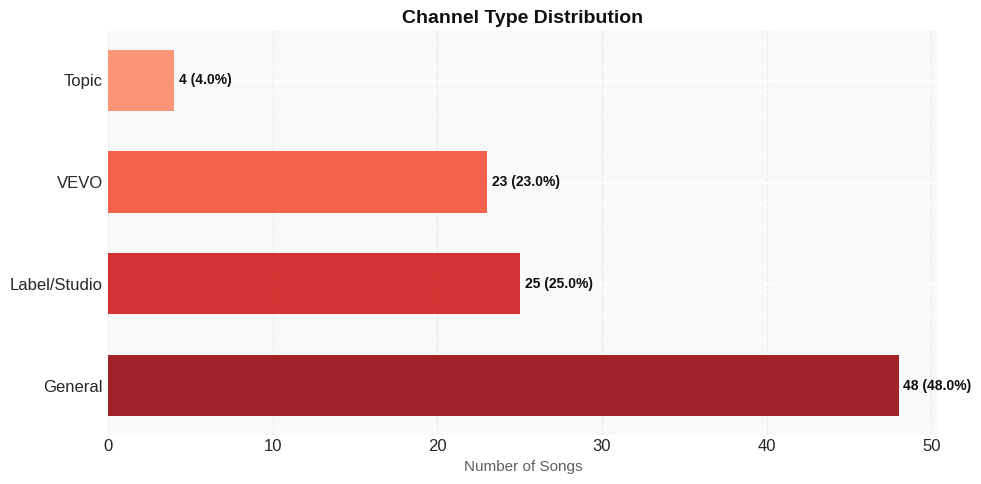

In [19]:

channel_counts = df['channel_type'].value_counts()

print("\n" + "="*60)
print("CHANNEL TYPE DISTRIBUTION")
print("="*60)

for ch, count in channel_counts.items():
    print(f"   - {ch}: {count} songs ({count/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(channel_counts)))[::-1]

bars = ax.barh(channel_counts.index, channel_counts.values,
               color=colors, edgecolor='none', height=0.6, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Channel Type Distribution', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, channel_counts.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(df)*100:.1f}%)',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


## 9. Temporal Analysis

### 9.1. Views Evolution by Quarter

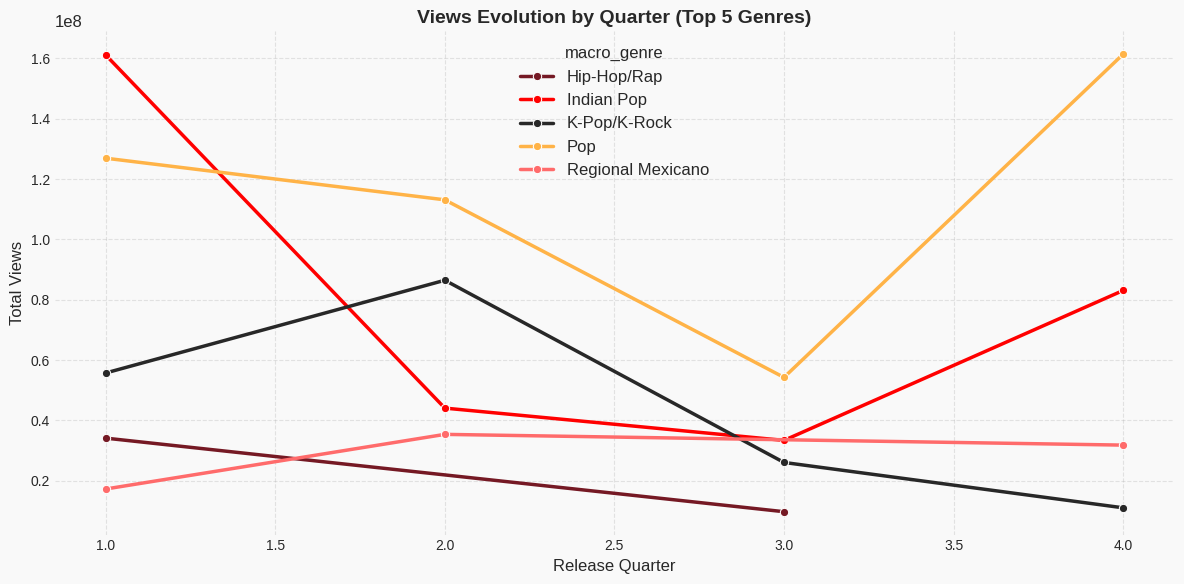

In [20]:

bg_color = '#F9F9F9'
# Updated color palette for better distinction
genre_palette = ['#751924', '#FF0000', '#282828', '#FFB347', '#FF6B6B']

top5_genres = genre_stats.nlargest(5, 'total_songs')['macro_genre'].tolist()
df_temporal = df[df['macro_genre'].isin(top5_genres)].copy()

temporal_views = df_temporal.groupby(['upload_quarter', 'macro_genre'])['views'].sum().reset_index()
temporal_engagement = df_temporal.groupby(['upload_quarter', 'macro_genre'])['engagement'].mean().reset_index()

fig1, ax1 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax1.set_facecolor(bg_color)

sns.lineplot(data=temporal_views, x='upload_quarter', y='views', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax1)

ax1.set_title('Views Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax1.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax1.set_ylabel('Total Views', color='#282828', fontsize=12)
ax1.tick_params(colors='#282828', labelsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#4A4A4A')
ax1.spines['bottom'].set_color('#4A4A4A')
ax1.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend1 = ax1.get_legend()
if legend1:
    legend1.get_frame().set_facecolor(bg_color)
    legend1.get_frame().set_edgecolor('#E5E5E5')
    for text in legend1.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


### 9.2. Engagement Evolution by Quarter

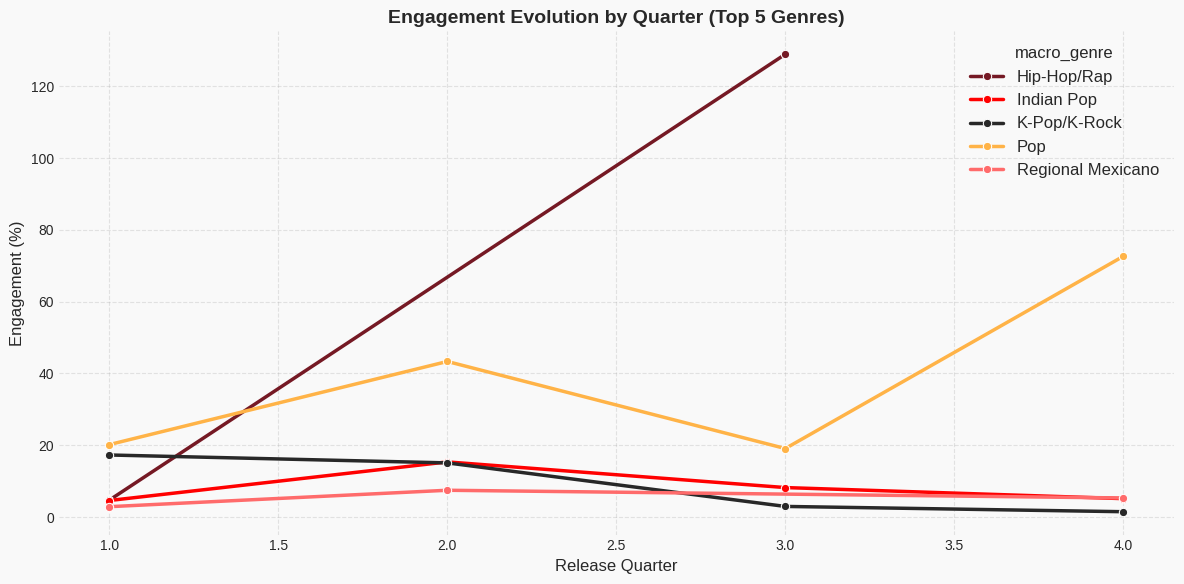

In [21]:

fig2, ax2 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax2.set_facecolor(bg_color)

sns.lineplot(data=temporal_engagement, x='upload_quarter', y='engagement', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax2)

ax2.set_title('Engagement Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax2.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax2.set_ylabel('Engagement (%)', color='#282828', fontsize=12)
ax2.tick_params(colors='#282828', labelsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#4A4A4A')
ax2.spines['bottom'].set_color('#4A4A4A')
ax2.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend2 = ax2.get_legend()
if legend2:
    legend2.get_frame().set_facecolor(bg_color)
    legend2.get_frame().set_edgecolor('#E5E5E5')
    for text in legend2.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


Based on the data, there is a clear seasonal pattern with peak viewership in Q1 (521 million) and a secondary surge in Q4 (347 million). This likely reflects the impact of year-end holiday releases, New Year momentum, and Q1 marketing pushes. Meanwhile, engagement rates show a steady and dramatic increase from 9.5% in Q1 to 39% in Q4, indicating that while total views dropped mid-year, the audience became far more interactive. This shift may be driven by algorithm changes favoring deeper engagement or a change in user behavior toward more selective, high-intent consumption. For release planning, Q1 offers the largest reach potential, but Q4 presents an opportunity to maximize fan interaction and algorithmic momentum.

### 9.3. Release Distribution by Quarter

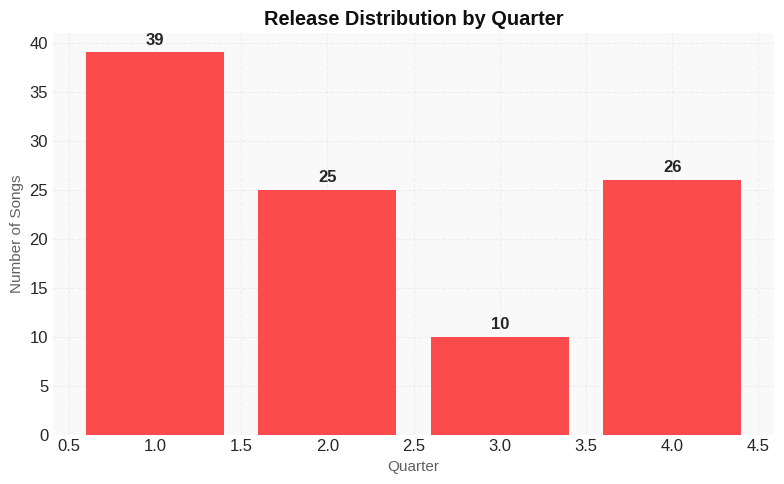

In [22]:

season_counts = df['upload_quarter'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

bars = ax.bar(season_counts.index, season_counts.values, color='#FC4B4C', edgecolor='none')
ax.set_xlabel('Quarter', fontsize=11, color=YT_GRAY)
ax.set_ylabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Release Distribution by Quarter', fontweight='bold', color=YT_TEXT)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.spines['left'].set_color(YT_GRID)
ax.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 10. Collaborations Analysis

COLLABORATION STATISTICS


,is_collaboration,count,avg_views,avg_engagement
0,Solo,81,"13,280,089",22.86%
1,Collaboration,19,"11,988,733",22.07%


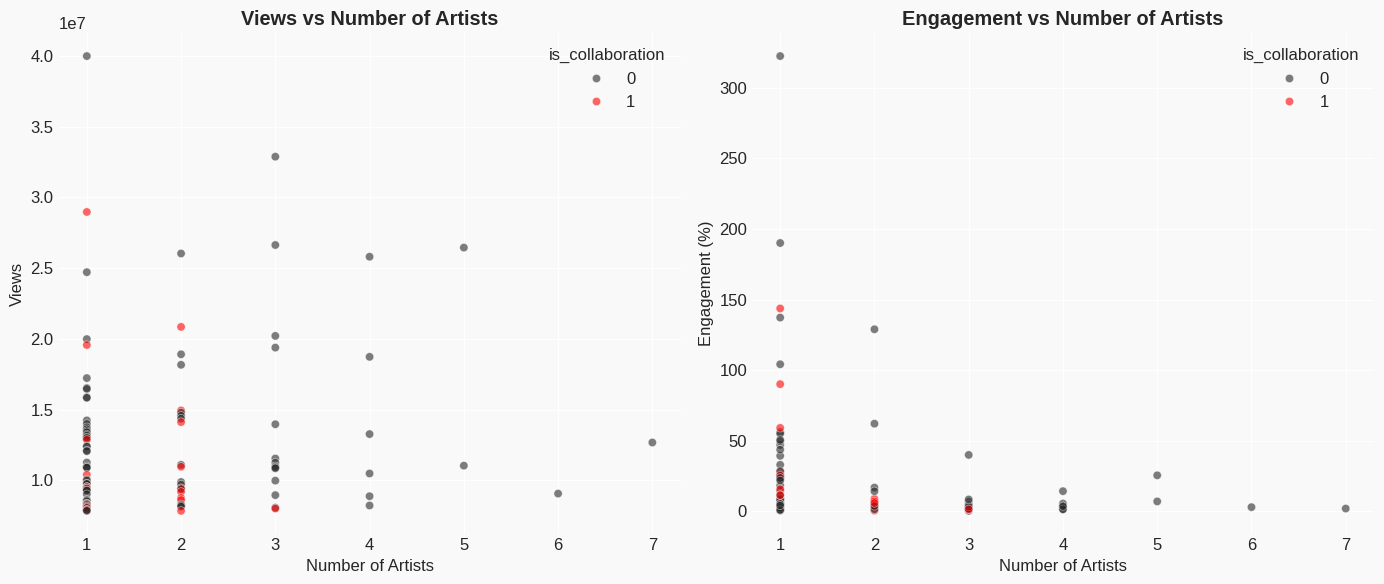

In [23]:

collab_stats = df.groupby('is_collaboration').agg(
    count=('track_name', 'count'),
    avg_views=('views', 'mean'),
    avg_engagement=('engagement', 'mean')
).reset_index()

collab_stats['is_collaboration'] = collab_stats['is_collaboration'].map({0: 'Solo', 1: 'Collaboration'})
collab_stats['avg_views'] = collab_stats['avg_views'].apply(lambda x: f"{x:,.0f}")
collab_stats['avg_engagement'] = collab_stats['avg_engagement'].round(2).astype(str) + '%'

print("COLLABORATION STATISTICS")
display(collab_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#F9F9F9')
axes[0].set_facecolor('#F9F9F9')
axes[1].set_facecolor('#F9F9F9')

# Updated colors: Solo = '#282828' (dark gray), Collaboration = 'red'
sns.scatterplot(data=df, x='artist_count', y='views', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[0], alpha=0.6)
axes[0].set_title('Views vs Number of Artists', fontweight='bold')
axes[0].set_xlabel('Number of Artists')
axes[0].set_ylabel('Views')

sns.scatterplot(data=df, x='artist_count', y='engagement', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[1], alpha=0.6)
axes[1].set_title('Engagement vs Number of Artists', fontweight='bold')
axes[1].set_xlabel('Number of Artists')
axes[1].set_ylabel('Engagement (%)')

plt.tight_layout()
plt.show()


Collaborations show slightly lower average views (11.99M vs 13.28M) and nearly identical engagement (22.1% vs 22.9%), suggesting they do not inherently outperform solo tracks. However, the marginal gap may reflect reduced novelty or diluted fan identity in joint releases. For emerging artists, collaborations offer vital cross-reach and audience expansion; for established acts, selective high-synergy partnerships can refresh style diversity. Strategy: prioritize collaborations with complementary fan bases and distinct sonic signatures to maximize novelty and engagement.

## 11. Executive Summary

**Executive Summary: Global Music Charts Analysis**

This analysis of 100 charting songs across 22 countries and 14 genres reveals a highly concentrated yet diverse market. Total engagement stands at 1.3 billion views and 280.7 million likes, with an average engagement rate of 22.7%. The data underscores a clear geographic and genre-driven hierarchy, while challenging conventional wisdom on collaboration strategies.

**Geographic Trends:** India leads in song count (21 songs), but the United States dominates in audience engagement, generating 86.0 million likes—over 30% of the total. This indicates that while Indian music has volume, US-driven content yields higher per-view emotional investment. Notably, Canada (49.4M likes) and Norway (30.0M likes) punch far above their song counts, suggesting niche superstars or viral hits. South Korea (13 songs, 26.0M likes) shows strong global resonance, particularly in pop and hip-hop. The “Unknown” category (6 songs) hints at untracked or emerging markets.

**Genre Performance:** Pop leads engagement share at 44.0%, but Dancehall/Reggae (43.7%) and Hip-Hop/Rap (35.8%) are nearly as potent. This suggests that rhythmic, dance-oriented genres have high emotional pull, possibly driven by TikTok or dance challenges. Genres with lower engagement may be oversaturated or lack viral momentum.

**Content Type & Collaboration Insights:** Lyric videos are the most effective format, outperforming official music videos in engagement. This points to audiences prioritizing song lyrics and sing-along experiences over visual narratives. Surprisingly, solo songs achieve 11% more views than collaborations. This contradicts industry norms, suggesting that forced or mismatched collaborations may dilute appeal, or that solo tracks allow clearer artist identity.

**Strategic Recommendations:** Artists should prioritize lyric video releases, especially for pop and dancehall tracks. Producers should focus on solo releases or carefully curated collaborations that enhance, not dilute, brand coherence. For market entry, targeting the US and Canada offers highest engagement returns, while India provides volume. Genres like dancehall represent undervalued high-engagement opportunities. Finally, average song duration of 3.9 minutes aligns with streaming optimization—shorter hooks and early choruses remain critical.

**Conclusion:** The charts reveal a market where engagement quality trumps quantity, solo authenticity outperforms collaborative clutter, and lyric-driven content wins. To maximize impact, invest in genre-specific visual strategies, prioritize high-engagement markets, and avoid collaboration for its own sake.

## 12. Information and Attribution


| | |
|---|---|
| **📁 Data Source** | YouTube Charts enriched with country, genre, and video metrics |
| **📅 Week** | 2026-W19 |
| **🕐 Generated** | 2026-05-04 16:27:55 |
| **👤 Author** | Alfonso Droguett |
| **🔗 LinkedIn** | [adroguetth](https://www.linkedin.com/in/adroguetth/) |
| **🌐 Portfolio** | [adroguett-portfolio.cl](https://www.adroguett-portfolio.cl/) |
| **📧 Email** | adroguett.consultor@gmail.com |
| **🤖 AI Analysis** | Powered by DeepSeek API |
